# Explore here

¡Datos cargados! Tenemos 768 pacientes y 9 variables.


/tmp/ipykernel_7023/3054103971.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Outcome', palette='Set2')


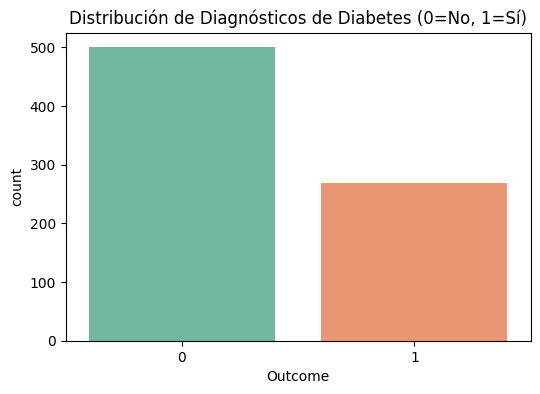

División completada:
- Entrenamiento: 614 pacientes.
- Prueba: 154 pacientes.


In [4]:
# Your code here
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# PASO 1: Carga del conjunto de datos
# Usamos un try-except por si el enlace de Heroku falla, usar el respaldo de GitHub
url_github = "https://raw.githubusercontent.com/4GeeksAcademy/decision-tree-project-tutorial/main/diabetes.csv"
url_heroku = "https://breathecode.herokuapp.com/asset/internal-link?id=930&path=diabetes.csv"

try:
    df = pd.read_csv(url_github)
except:
    df = pd.read_csv(url_heroku)

print(f"¡Datos cargados! Tenemos {df.shape[0]} pacientes y {df.shape[1]} variables.")

# PASO 2: Análisis Exploratorio Rápido (EDA)
# Veamos cuántos pacientes tienen diabetes (1) y cuántos no (0)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Outcome', palette='Set2')
plt.title('Distribución de Diagnósticos de Diabetes (0=No, 1=Sí)')
plt.show()

# Las variables ya son todas numéricas, así que pasamos directo a dividir los datos
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Dividimos en Train y Test (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"División completada:")
print(f"- Entrenamiento: {X_train.shape[0]} pacientes.")
print(f"- Prueba: {X_test.shape[0]} pacientes.")


--- RESULTADOS DE LAS FUNCIONES DE PUREZA ---
Precisión del Árbol con Gini: 0.7468
Precisión del Árbol con Entropía: 0.7208


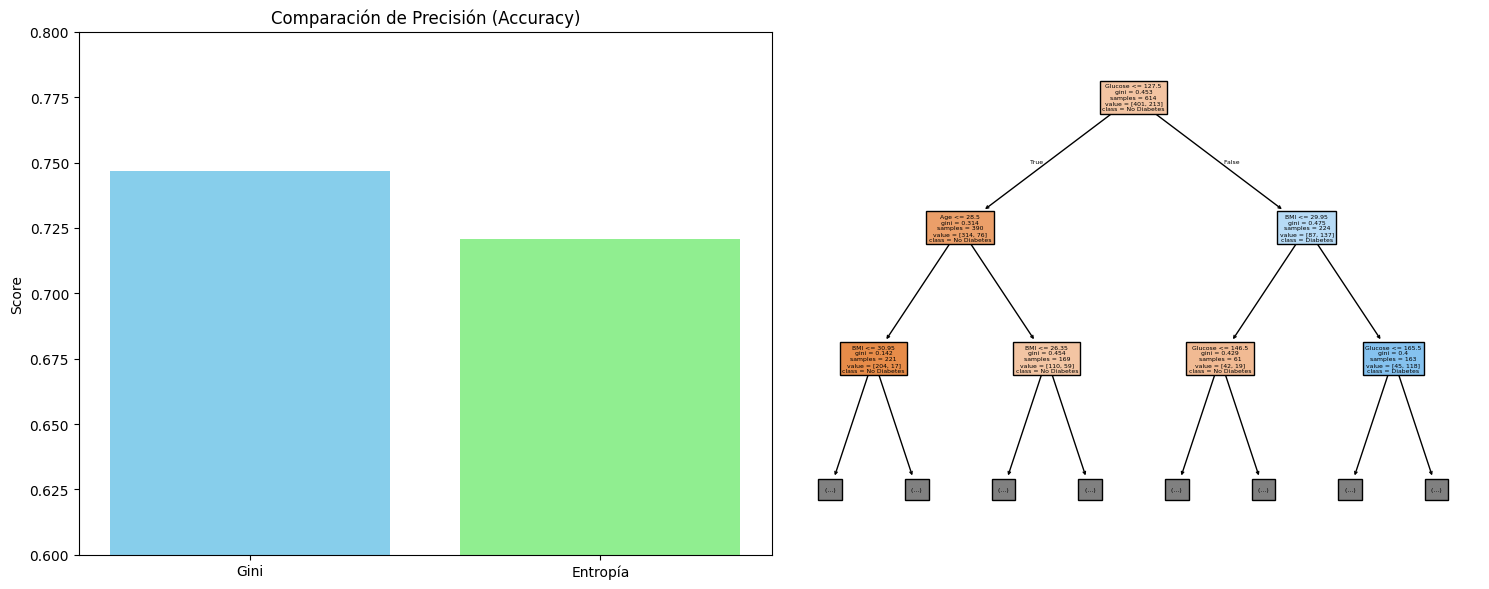

In [5]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# --- 1. MODELO CON CRITERIO GINI ---
tree_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
tree_gini.fit(X_train, y_train)
y_pred_gini = tree_gini.predict(X_test)
acc_gini = accuracy_score(y_test, y_pred_gini)

# --- 2. MODELO CON CRITERIO ENTROPÍA ---
tree_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
tree_entropy.fit(X_train, y_train)
y_pred_entropy = tree_entropy.predict(X_test)
acc_entropy = accuracy_score(y_test, y_pred_entropy)

print("--- RESULTADOS DE LAS FUNCIONES DE PUREZA ---")
print(f"Precisión del Árbol con Gini: {acc_gini:.4f}")
print(f"Precisión del Árbol con Entropía: {acc_entropy:.4f}")

# --- 3. GRÁFICOS (Comparación y Estructura) ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico A: Comparación de precisión
axes[0].bar(['Gini', 'Entropía'], [acc_gini, acc_entropy], color=['skyblue', 'lightgreen'])
axes[0].set_ylim(0.6, 0.8) # Ajustamos la escala para notar la diferencia
axes[0].set_title('Comparación de Precisión (Accuracy)')
axes[0].set_ylabel('Score')

# Gráfico B: Visualización de las primeras ramas del Árbol Gini
axes[1].set_title('Estructura del Árbol de Decisión (Primeros 2 niveles)')
# Dibujamos solo los primeros 2 niveles (max_depth=2) para que se pueda leer en pantalla
plot_tree(tree_gini, feature_names=X.columns, class_names=['No Diabetes', 'Diabetes'], filled=True, max_depth=2, ax=axes[1])

plt.tight_layout()
plt.show()

In [6]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
import pickle

# 1. ELEGIMOS EL CRITERIO GANADOR
# Como Gini obtuvo mejor puntuación, lo fijamos como nuestro criterio base.

# 2. DEFINIMOS LA "CUADRÍCULA" DE HIPERPARÁMETROS (Grid)
# Aquí le decimos al modelo qué combinaciones queremos que pruebe.
param_grid = {
    'criterion': ['gini'],
    'max_depth': [None, 3, 4, 5, 6, 7], # max_depth: ¿Cuántos niveles de profundidad puede tener el árbol? (Evita que crezca infinito)
    'min_samples_split': [2, 5, 10],    # min_samples_split: ¿Cuántos pacientes mínimo debe haber en un nodo para permitirle dividirse de nuevo?
    'min_samples_leaf': [1, 2, 4]       # min_samples_leaf: ¿Cuántos pacientes mínimo debe haber en la "hoja" final (la conclusión)?
}

# 3. CONFIGURAMOS EL GRID SEARCH
# Le pasamos nuestro árbol base, la cuadrícula de opciones, y le pedimos que evalúe usando 'accuracy' (precisión).
# cv=5 significa "Cross-Validation": dividirá los datos internamente 5 veces para asegurarse de que el resultado no sea por suerte.
grid_search = GridSearchCV(estimator=DecisionTreeClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=5,
                           scoring='accuracy')

# 4. ¡A ENTRENAR TODAS LAS COMBINACIONES!
# Esto puede tardar unos segundos porque está creando y evaluando decenas de árboles distintos.
grid_search.fit(X_train, y_train)

# 5. OBTENEMOS EL ÁRBOL GANADOR DEFINITIVO
best_tree = grid_search.best_estimator_

# Hacemos la predicción final con los datos de Test
y_pred_opt = best_tree.predict(X_test)
acc_opt = accuracy_score(y_test, y_pred_opt)

print("--- RESULTADOS DE LA OPTIMIZACIÓN (GRID SEARCH) ---")
print(f"La mejor combinación de reglas encontrada fue:\n{grid_search.best_params_}")
print(f"\nNueva Precisión Optimizada: {acc_opt:.4f}")

# PASO 5: GUARDAR EL MODELO
# Almacenamos nuestro árbol campeón en un archivo .pkl
with open('decision_tree_model.pkl', 'wb') as file:
    pickle.dump(best_tree, file)

print("\n¡Modelo optimizado y guardado con éxito como 'decision_tree_model.pkl'!")

--- RESULTADOS DE LA OPTIMIZACIÓN (GRID SEARCH) ---
La mejor combinación de reglas encontrada fue:
{'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 4, 'min_samples_split': 2}

Nueva Precisión Optimizada: 0.7013

¡Modelo optimizado y guardado con éxito como 'decision_tree_model.pkl'!


Conclusión del Modelo:
En la predicción de diagnósticos de diabetes, el árbol de decisión utilizando el criterio de Impureza de Gini superó ligeramente a la Entropía en su versión base.

Para evitar el sobreajuste (overfitting), aplicamos una optimización de hiperparámetros mediante Grid Search. El algoritmo determinó la profundidad máxima ideal y las reglas mínimas de división de nodos, entregándonos un modelo final robusto que fue guardado exitosamente como decision_tree_model.pkl para su posterior pase a producción.